### Clustering Molecules With a Self-Organizing Map (SOM)
This notebook provides an overview of the use of self-organizing maps (SOMs) in cheminformatics. For a bit of background on SOMs, please see this [blog post](http://practicalcheminformatics.blogspot.com/2018/10/self-organizing-maps-90s-fad-or-useful.html)

In [2]:
%pip install minisom tqdm rdkit mols2grid

  Using cached minisom-2.3.6.tar.gz (13 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for minisom: filename=minisom-2.3.6-py3-none-any.whl size=13171 sha256=45684791b3483d7e80c1c03bc9afd0b1b6615655dfd83fea311ce17d298fc704
  Stored in directory: /Users/illiakocherovets/Library/Caches/pip/wheels/db/64/f5/9cd874e0fb11e514fb6230dc7c11c80da48227bd698e50b5f2
Successfully built minisom

[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Import the necessary Python libraries

In [3]:
from collections import Counter
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
from rdkit import Chem
from rdkit.Chem import MACCSkeys
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs
import numpy as np
from tqdm.auto import tqdm
from minisom import MiniSom
import sys
from time import time
import mols2grid
from ipywidgets import interact
from rdkit import rdBase

Enable matplotlib plots in this notebook

In [4]:
%matplotlib inline

#### Defining a Few Useful Functions
A few functions to generate fingerprints. The first function generates 166-bit MACCS keys.  The second generates Morgan fingerprints.  While both will work for building a SOM, the process will be a bit faster with MACCS keys. I tend to like MACCS keys for generating SOMs.  These fingerprints typically do a good job of grouping a set of molecules by scaffold. The third function takes a list of SMILES as input and returns as a list of fingerprints. If this function is called with one argument, it generates MACCS keys.  We can also pass a function as a second argument to generate a different fingerprint type.  For instance, we could call it like this to generate Morgan fingerprints.  
```
generate_fps(my_smiles_list,morgan_as_np)
```

In [5]:
def maccs_as_np(mol):
    """
    Generate MACCS fingerprints as a NumPy array
    :param mol: input molecule
    :return: fingerprint as a NumPy array
    """
    bv = MACCSkeys.GenMACCSKeys(mol)
    return np.array([int(x) for x in list(bv.ToBitString())], dtype=np.float32)


morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=1024)


def morgan_as_np(mol):
    """
    Generate a 1024 bit Morgan fingerprint as a NumPy array
    :param mol: input molecule
    :return: fingerprint as a NumPy array
    """
    bv = morgan_gen.GetFingerprint(mol)
    arr = np.zeros((1,), dtype=np.float32)
    DataStructs.ConvertToNumpyArray(bv, arr)
    return arr


def generate_fps(smiles_list, fp_function=maccs_as_np):
    """
    Take a list of SMILES as input and return a list of NumPy arrays
    :param smiles_list: list of SMILES
    :param fp_function: function to calculate fingerprints
    :return: list of NumPy arrays containing fingerprints
    """
    output_fp_list = []
    for smiles in tqdm(smiles_list, desc="Generating Fingerprints"):
        output_fp_list.append(fp_function(Chem.MolFromSmiles(smiles)))
    return output_fp_list

A function to generate a grid of pie charts showing the distribution of active and inactive compounds in each grid cell. 

In [6]:
# Adapted from the MiniSom example notebook
def depict_som(cluster_df, x_dim, y_dim, x_column="X", y_column="Y", activity_column="is_active"):
    """
    Draw a SOM with each cell depicted as a pie chart
    :param cluster_df: data frame with SOM output, should have columns active, X, and Y
    :param x_dim: X dimension of the SOM
    :param y_dim: Y dimension of the SOM
    :return:
    """
    required_colums = [x_column, y_column, activity_column]
    for col in required_colums:
        if col not in cluster_df.columns:
            print(f"Error {col} not in dataframe columns", file=sys.stderr)
            sys.exit(1)
    cell_dict = {}
    for k, v in [x for x in cluster_df.groupby([x_column, y_column])]:
        cell_dict[k] = Counter(v[activity_column])
        cell_names = cluster_df[activity_column].unique()
    plt.figure(figsize=(x_dim, y_dim))
    the_grid = GridSpec(x_dim, y_dim)
    for position in cell_dict.keys():
        label_fracs = [cell_dict[position][x] for x in cell_names]
        plt.subplot(the_grid[(x_dim - 1) - position[1], position[0]], aspect=1)
        patches, texts = plt.pie(label_fracs)

Build a SOM with minisom

In [8]:
def build_minisom_som(fp_list_in, x_dim=10, y_dim=10, num_iters=20000):
    """
    Build a SOM with MiniSom
    :param fp_list_in: input list of fingerprints as NumPy arrays
    :param x_dim: X dimension of the SOM
    :param y_dim: Y dimension of the SOM
    :param num_iters: number of iterations when building the SOM
    :return: lists with X and Y coordinates in the SOM
    """
    print("Training SOM")
    start_time = time()
    som = MiniSom(x_dim, y_dim, len(fp_list_in[0]), sigma=0.3, learning_rate=0.5, random_seed=1)
    som.train_random(fp_list_in, num_iters)
    x = []
    y = []
    # find best matching units
    print("Finding BMUs")
    for row in fp_list_in:
        x_val, y_val = som.winner(row)
        x.append(x_val)
        y.append(y_val)
    elapsed_time = time()-start_time
    print("Done\nElapsed time = %.2f sec" % elapsed_time)
    return x, y

#### Reading the Input Data
Now that we have the necessary functions in place, we can have some fun.  We will read in a csv file containing SMILES, a molecule name, and 1 or 0 indicating that the molecule is active into a Pandas data frame. 

We then use the function generate_fps to generate a list of fingerprints from the SMILES column in the dataframe. This list of fingerprints is then used to generate X and Y coordinates for each molecule in the grid.  The x and y coordinates generated by build_minisom_som are then added as columns to the original dataframe.  This dataframe, as well as the grid dimensions, are then passed to the depiction function to generate the plot below. 

In [11]:
import sys
sys.path.append("..")

from read_csv import read_csv

act_df = read_csv("https://raw.githubusercontent.com/PatWalters/practical_cheminformatics_tutorials/main/data/dude_erk2_mk01.csv")
act_df.head()

,Unnamed: 0,SMILES,ID,is_active
0,0,Cn1ccnc1Sc2ccc(cc2Cl)Nc3c4cc(c(cc4ncc3C#N)OCCC...,168691,1
1,1,C[C@@]12[C@@H]([C@@H](CC(O1)n3c4ccccc4c5c3c6n2...,86358,1
2,2,Cc1cnc(nc1c2cc([nH]c2)C(=O)N[C@H](CO)c3cccc(c3...,575087,1
3,3,Cc1cnc(nc1c2cc([nH]c2)C(=O)N[C@H](CO)c3cccc(c3...,575065,1
4,4,Cc1cnc(nc1c2cc([nH]c2)C(=O)N[C@H](CO)c3cccc(c3...,575047,1


#### Adding Labels
Active and decoy are currently indicated by 1 and 0 in the dataframe.  To have better labels, we will convert 1 and 0 to the strings **active** and **decoy** and add new column called **label**.

In [12]:
act_df['label'] = ["active" if i == 1 else "inactive" for i in act_df.is_active]

In [13]:
act_df.label.value_counts()

label
inactive    4550
active        79
Name: count, dtype: int64

In [14]:
act_df.head()

,Unnamed: 0,SMILES,ID,is_active,label
0,0,Cn1ccnc1Sc2ccc(cc2Cl)Nc3c4cc(c(cc4ncc3C#N)OCCC...,168691,1,active
1,1,C[C@@]12[C@@H]([C@@H](CC(O1)n3c4ccccc4c5c3c6n2...,86358,1,active
2,2,Cc1cnc(nc1c2cc([nH]c2)C(=O)N[C@H](CO)c3cccc(c3...,575087,1,active
3,3,Cc1cnc(nc1c2cc([nH]c2)C(=O)N[C@H](CO)c3cccc(c3...,575065,1,active
4,4,Cc1cnc(nc1c2cc([nH]c2)C(=O)N[C@H](CO)c3cccc(c3...,575047,1,active


#### Building and Displaying the SOM
Now we'll generate fingerprints for the molecules, the build and display the SOM.

The dataset we used above is the [ERK2 (aka MK01)](http://dude.docking.org/targets/mk01) dataset that is part of the [DUD-E dataset](http://dude.docking.org/), which was designed for the evaluation of docking programs.  The DUDE-E database consists of sets of active compounds, curated from the literature, and decoy compounds with similar calculated properties (molecular weight, LogP).  The compound sets in the database were designed to evaluate the ability of a docking program to distinguish active compounds from decoys.  

In the plot below, the active compounds are shown in blue, while the decoy compounds are shown in orange.  As we can see, our fingerprints do a reasonably good job of separating the active compounds from the decoys.  In particular, we see that one cell at position 6,4 (we start counting from 0) is highly enriched in active compounds.  Let's take a closer look at molecules in that cell.  

Generating Fingerprints:   0%|          | 0/4629 [00:00<?, ?it/s]

Training SOM
Finding BMUs
Done
Elapsed time = 5.87 sec


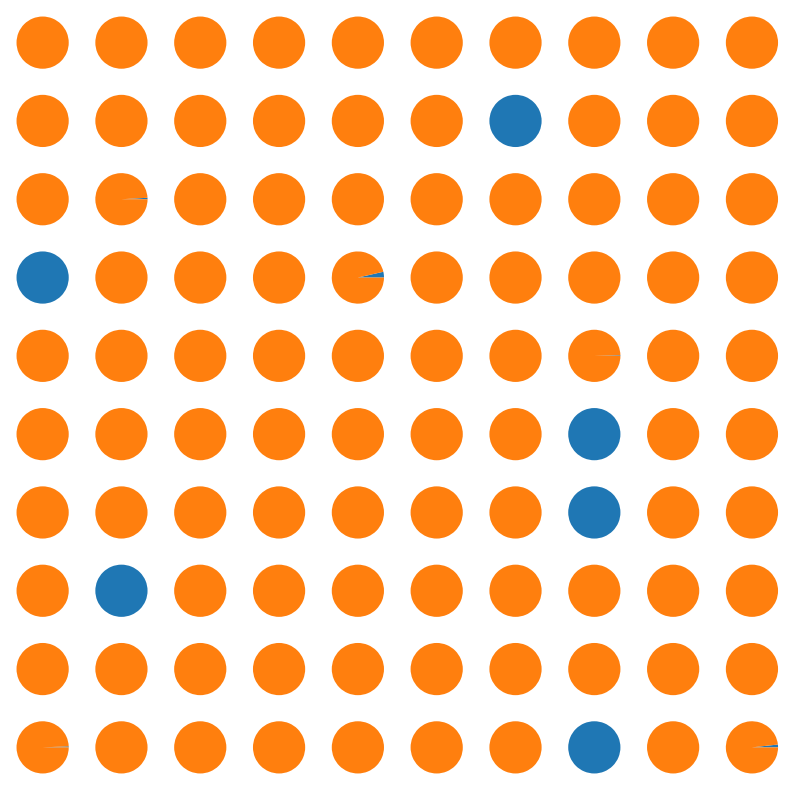

In [15]:
with rdBase.BlockLogs():
    morgan_list = generate_fps(act_df.SMILES,morgan_as_np)
x_dim = 10
y_dim = 10
morgan_x, morgan_y = build_minisom_som(morgan_list, x_dim, y_dim)
act_df["morgan_X"] = morgan_x
act_df["morgan_Y"] = morgan_y
depict_som(act_df, x_dim, y_dim, x_column="morgan_X",y_column="morgan_Y")

#### Creating an Interactive Viewer
Let's define a function that will display the molecules in a particular cell.  We'll use the Jupyter [interact](https://colab.research.google.com/github/jupyter-widgets/ipywidgets/blob/master/docs/source/examples/Using%20Interact.ipynb) widget to make an interactive tool.  Note that cells are numbered from 0, with cell (0,0) in the bottom left corner. 

In [16]:
@interact(x=range(0,x_dim), y=range(0,y_dim))
def display_mols(x, y):
    return mols2grid.display(act_df.query("morgan_X==@x and morgan_Y==@y"),subset=["img","ID","label"])

interactive(children=(Dropdown(description='x', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9), value=0), Dropdown(des…

# Clustering Molecules With a Self-Organizing Map (SOM) — Full Summary

This notebook is the next step after the SOM blog post (the one with colors) — except now, instead of colors, we organize **molecules**.

## The big idea

In the earlier notebooks you sorted molecules into piles (k-means, Taylor-Butina). A SOM does something similar, but with a bonus: it lays the molecules out on a **2D grid so that similar molecules end up in neighbouring cells**. So you don't just get groups — you get a **map** you can look at with your eyes and see where in "chemical space" the active compounds cluster.

Remember the color map from the blog post: similar colors sit next to each other. Same thing here, but instead of a color (3 RGB numbers) each molecule is described by a fingerprint (hundreds of numbers). The algorithm is identical; only what we feed it changes.

## The data

The same ERK2 set from DUD-E as in the previous notebook: 4629 molecules, of which only **79 are active** and **4550 are decoys**. This is a deliberately built set where the decoys resemble the actives on simple properties (mass, LogP), to test whether a method can still tell them apart. So the task is hard — very few actives, and they're "camouflaged".

## Step by step

### 1. Fingerprint functions
Three functions are defined:
- `maccs_as_np` — makes **MACCS keys** (166 bits). The author likes them for SOMs because they group molecules well by scaffold, and they're faster.
- `morgan_as_np` — makes a **Morgan fingerprint** (1024 bits), more detailed.
- `generate_fps` — takes a list of SMILES and returns a list of fingerprints. Defaults to MACCS, but you can pass a different function (as done here with `morgan_as_np`).

This is just prep: turn molecules into numeric vectors the SOM can eat.

### 2. Map-drawing function `depict_som`
Draws a grid where **each cell is a small pie chart** showing how many active and inactive molecules are in that cell. This makes it instantly visible where the actives cluster.

### 3. SOM-building function `build_minisom_som`
Here a ready-made library, **minisom**, is used (we don't write the algorithm from scratch as we did for colors). It:
- creates a 10×10 grid,
- trains it on the fingerprints (`train_random`, 20000 iterations),
- for each molecule finds its **BMU** (best matching unit — the closest cell, via `som.winner(...)`),
- returns the X and Y coordinates of each molecule on the grid.

This is the same algorithm you implemented by hand for colors, just wrapped in a library.

### 4. Reading data and labels
Read the CSV (again via `read_csv` with `sys.path.append("..")`). Then convert 1/0 into readable text labels:
```python
act_df['label'] = ["active" if i == 1 else "inactive" for i in act_df.is_active]
```
`value_counts()` confirms the split: 4550 inactive, 79 active.

### 5. Building and showing the map
```python
with rdBase.BlockLogs():
    morgan_list = generate_fps(act_df.SMILES, morgan_as_np)
morgan_x, morgan_y = build_minisom_som(morgan_list, 10, 10)
act_df["morgan_X"] = morgan_x
act_df["morgan_Y"] = morgan_y
depict_som(...)
```
Generated Morgan fingerprints, built the SOM, added each molecule's X/Y coordinates to the table, and drew the pie-chart map. (`rdBase.BlockLogs()` just silences a pile of RDKit warnings so they don't clutter the output.)

**Result:** on the map, actives are blue, decoys orange. You can see the fingerprints **separate actives from decoys reasonably well** — in particular cell **(6,4)** is strongly enriched in actives. So the method worked: even though there are only 79 actives out of 4629, they gathered in a corner of the map rather than smearing out evenly.

### 6. Interactive viewer
```python
@interact(x=range(0,x_dim), y=range(0,y_dim))
def display_mols(x, y):
    return mols2grid.display(act_df.query("morgan_X==@x and morgan_Y==@y"), ...)
```
`@interact` is Jupyter magic that makes **interactive sliders/dropdowns**. You pick a cell's coordinates (x, y), and the function shows the real structures of the molecules in exactly that cell. So you can click on a "hot" cell like (6,4) and inspect what those active molecules are.

## Color vs position — the key insight

The color and the position come from two different places:

- **Color** comes straight from the `is_active` column in your data — a known answer, laid onto the map after the fact. The SOM did not compute it.
- **Position** was computed by the SOM from **fingerprints only**, with no knowledge of activity.

The SOM never saw the labels, yet the blue (active) molecules still gathered into a few cells. That means structurally similar molecules are also similar in activity — a confirmation of the *similar property principle*. (Analogy: arrange people by height and weight only, then color basketball players blue; if the blue ones cluster in one corner, size really is linked to the sport.)

## Why do all this (what the SOM adds)

Three things a SOM gives that plain clustering does not:

1. **A visual map.** You don't just get groups, you *see* their relative arrangement. Neighbouring cells = similar molecules. Hard to get from k-means.
2. **Finding activity zones (SAR).** If actives gather in one corner, that hints at which structural type drives activity. Cell (6,4) is exactly such a finding.
3. **Comparing compound sets.** You can overlay two molecule libraries on one map and see which regions of chemical space each covers.

In plain words: **a SOM turns thousands of high-dimensional molecules into a flat "atlas" where you can point at an interesting region and look at what lives there.**

## What was new compared to previous notebooks

- **SOM instead of k-means / Butina** — gives a map, not just group labels.
- **The minisom library** instead of a hand-written implementation.
- **Two fingerprint types** (MACCS vs Morgan) and the ability to pass a function as an argument.
- **Pie-chart visualization** (`depict_som`) for activity distribution.
- **`@interact`** — interactive exploration of cells right in the notebook.

## One caveat

The exact coordinates of the blue cells may not match the blog post. A SOM has random initialization, so the map is slightly different each run — what matters is not the exact cell number, but the fact that the actives grouped together.